In [1]:
import matplotlib.pyplot as plt
import numpy as np
import sumo_rl
import torch
import torch.nn as nn
import torch.optim as optim
import random
from collections import deque

In [2]:
# Hyperparameters
gamma = 0.99
epsilon = 1.0
epsilon_min = 0.05
epsilon_decay = 0.95
batch_size = 64
learning_rate = 1e-3
num_seconds=1800
episodes = 50

In [3]:
# Initialize raw PettingZoo environment
env = sumo_rl.parallel_env(
    net_file="./env/3x3Grid2lanes.net.xml",
    route_file="./env/routes14000.rou.xml",
    use_gui=False, # Keep False for training
    num_seconds=num_seconds,
    delta_time=5,
    reward_fn="pressure",
)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 45ms, vehicles TOT 0 ACT 0 BUF 0)                     


In [4]:
# Get dimensions for the network
sample_agent = env.possible_agents[0]
obs_dim = env.observation_space(sample_agent).shape[0]
action_dim = env.action_space(sample_agent).n

In [5]:
class QNetwork(nn.Module):
    def __init__(self, obs_dim, action_dim):
        super(QNetwork, self).__init__()
        self.fc1 = nn.Linear(obs_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, action_dim)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        return self.fc3(x)

In [6]:
# Initialize Network, Optimizer, and Buffer
q_net = QNetwork(obs_dim, action_dim)
optimizer = optim.Adam(q_net.parameters(), lr=learning_rate)
loss_fn = nn.MSELoss()
replay_buffer = deque(maxlen=10000)

In [7]:
all_episode_rewards = []

for episode in range(episodes):
    observations, infos = env.reset()
    episode_reward = 0
    
    while env.agents:
        actions = {}
        
        # --- 1. Epsilon-Greedy Action Selection ---
        for agent in env.agents:
            obs_tensor = torch.FloatTensor(observations[agent]).unsqueeze(0)
            
            if random.random() < epsilon:
                # Explore
                actions[agent] = env.action_space(agent).sample()
            else:
                # Exploit
                with torch.no_grad():
                    q_values = q_net(obs_tensor)
                    actions[agent] = torch.argmax(q_values).item()

        # --- 2. Step the Environment ---
        next_observations, rewards, terminations, truncations, infos = env.step(actions)

        # --- 3. Store Transitions in Shared Buffer ---
        for agent in env.agents:
            replay_buffer.append((
                observations[agent], 
                actions[agent], 
                rewards[agent], 
                next_observations[agent], 
                terminations[agent] or truncations[agent]
            ))
            episode_reward += rewards[agent]

        observations = next_observations

        # --- 4. Train the Q-Network ---
        if len(replay_buffer) > batch_size:
            # Sample a batch
            batch = random.sample(replay_buffer, batch_size)
            b_obs, b_act, b_rew, b_next_obs, b_done = zip(*batch)
            
            b_obs = torch.FloatTensor(np.array(b_obs))
            b_act = torch.LongTensor(b_act).unsqueeze(1)
            b_rew = torch.FloatTensor(b_rew).unsqueeze(1)
            b_next_obs = torch.FloatTensor(np.array(b_next_obs))
            b_done = torch.FloatTensor(b_done).unsqueeze(1)

            # Compute Current Q values
            current_q = q_net(b_obs).gather(1, b_act)
            
            # Compute Target Q values (Note: A separate Target Network is recommended for stability)
            with torch.no_grad():
                max_next_q = q_net(b_next_obs).max(1)[0].unsqueeze(1)
                target_q = b_rew + (gamma * max_next_q * (1 - b_done))
            
            # Optimize
            loss = loss_fn(current_q, target_q)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    all_episode_rewards.append(episode_reward)

    # Decay Epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    print(f"Episode {episode + 1} | Total Shared Reward: {episode_reward:.2f} | Epsilon: {epsilon:.2f}")

env.close()

 Retrying in 1 seconds
Episode 1 | Total Shared Reward: -9076.00 | Epsilon: 0.95
Step #1800.00 (2ms ~= 500.00*RT, ~102000.00UPS, TraCI: 207ms, vehicles TOT 900 ACT 204 BUF
 Retrying in 1 seconds


Episode 2 | Total Shared Reward: -7579.00 | Epsilon: 0.90ms, vehicles TOT 351 ACT 81 BUF 0
Step #1800.00 (1ms ~= 1000.00*RT, ~145000.00UPS, TraCI: 167ms, vehicles TOT 900 ACT 145 BU
 Retrying in 1 seconds
Episode 3 | Total Shared Reward: -6133.00 | Epsilon: 0.86
Step #1800.00 (1ms ~= 1000.00*RT, ~104000.00UPS, TraCI: 140ms, vehicles TOT 900 ACT 104 BU
 Retrying in 1 seconds
Episode 4 | Total Shared Reward: -6074.00 | Epsilon: 0.81
Step #1800.00 (1ms ~= 1000.00*RT, ~93000.00UPS, TraCI: 117ms, vehicles TOT 900 ACT 93 BUF 
 Retrying in 1 seconds
Episode 5 | Total Shared Reward: -6471.00 | Epsilon: 0.77
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 91ms, vehicles TOT 900 ACT 78 BUF 0)                
 Retrying in 1 seconds
Episode 6 | Total Shared Reward: -5496.00 | Epsilon: 0.74
Step #1800.00 (1ms ~= 1000.00*RT, ~67000.00UPS, TraCI: 110ms, vehicles TOT 900 ACT 67 BUF 
 Retrying in 1 seconds
Episode 7 | Total Shared Reward: -5169.00 | Epsilon: 0.70
Step #1800.00 (1ms ~= 1000.00*RT, ~64000.00UPS, T

Episode 18 | Total Shared Reward: -3848.00 | Epsilon: 0.40
Step #1800.00 (1ms ~= 1000.00*RT, ~57000.00UPS, TraCI: 72ms, vehicles TOT 900 ACT 57 BUF 0
 Retrying in 1 seconds
Episode 19 | Total Shared Reward: -3879.00 | Epsilon: 0.38
Step #1800.00 (1ms ~= 1000.00*RT, ~53000.00UPS, TraCI: 65ms, vehicles TOT 900 ACT 53 BUF 0
 Retrying in 1 seconds
Episode 20 | Total Shared Reward: -3865.00 | Epsilon: 0.36
Step #1800.00 (1ms ~= 1000.00*RT, ~52000.00UPS, TraCI: 59ms, vehicles TOT 900 ACT 52 BUF 0
 Retrying in 1 seconds
Episode 21 | Total Shared Reward: -3720.00 | Epsilon: 0.34
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 71ms, vehicles TOT 900 ACT 47 BUF 0)                
 Retrying in 1 seconds
Episode 22 | Total Shared Reward: -3880.00 | Epsilon: 0.32
Step #1800.00 (1ms ~= 1000.00*RT, ~54000.00UPS, TraCI: 70ms, vehicles TOT 900 ACT 54 BUF 0
 Retrying in 1 seconds
Episode 23 | Total Shared Reward: -3624.00 | Epsilon: 0.31
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 75ms, vehicles TOT 900 ACT 49 BUF 0)  

Episode 30 | Total Shared Reward: -3563.00 | Epsilon: 0.21
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 70ms, vehicles TOT 900 ACT 45 BUF 0)                
 Retrying in 1 seconds
Episode 31 | Total Shared Reward: -3486.00 | Epsilon: 0.20
Step #1800.00 (1ms ~= 1000.00*RT, ~41000.00UPS, TraCI: 84ms, vehicles TOT 900 ACT 41 BUF 0
 Retrying in 1 seconds
Episode 32 | Total Shared Reward: -3650.00 | Epsilon: 0.19
Step #1800.00 (1ms ~= 1000.00*RT, ~48000.00UPS, TraCI: 71ms, vehicles TOT 900 ACT 48 BUF 0
 Retrying in 1 seconds
Episode 33 | Total Shared Reward: -3609.00 | Epsilon: 0.18
Step #1800.00 (1ms ~= 1000.00*RT, ~46000.00UPS, TraCI: 71ms, vehicles TOT 900 ACT 46 BUF 0
 Retrying in 1 seconds
Episode 34 | Total Shared Reward: -3565.00 | Epsilon: 0.17
Step #1800.00 (1ms ~= 1000.00*RT, ~45000.00UPS, TraCI: 76ms, vehicles TOT 900 ACT 45 BUF 0
 Retrying in 1 seconds
Episode 35 | Total Shared Reward: -3410.00 | Epsilon: 0.17
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 70ms, vehicles TOT 900 ACT 45 BUF 0)  

Episode 44 | Total Shared Reward: -3342.00 | Epsilon: 0.10
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 80ms, vehicles TOT 900 ACT 43 BUF 0)                
 Retrying in 1 seconds
Episode 45 | Total Shared Reward: -3351.00 | Epsilon: 0.10
Step #1800.00 (1ms ~= 1000.00*RT, ~48000.00UPS, TraCI: 69ms, vehicles TOT 900 ACT 48 BUF 0
 Retrying in 1 seconds
Episode 46 | Total Shared Reward: -3358.00 | Epsilon: 0.09
Step #1800.00 (1ms ~= 1000.00*RT, ~44000.00UPS, TraCI: 67ms, vehicles TOT 900 ACT 44 BUF 0
 Retrying in 1 seconds
Episode 47 | Total Shared Reward: -3347.00 | Epsilon: 0.09
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 66ms, vehicles TOT 900 ACT 43 BUF 0)                
 Retrying in 1 seconds
Episode 48 | Total Shared Reward: -3303.00 | Epsilon: 0.09
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 76ms, vehicles TOT 900 ACT 41 BUF 0)                
 Retrying in 1 seconds
Episode 49 | Total Shared Reward: -3315.00 | Epsilon: 0.08
Step #1800.00 (0ms ?*RT. ?UPS, TraCI: 81ms, vehicles TOT 900 ACT 41 BUF 0)  

In [8]:
model_path = "./models/3x3-v2.pth"
torch.save(q_net.state_dict(), model_path)

In [11]:
def plot_rewards(rewards):
    plt.figure(figsize=(10, 5))
    
    plt.plot(rewards, label='Episode Reward', color='dodgerblue', alpha=0.75)
    
    plt.title('Independent DQN Training over 3x3 SUMO Grid')
    plt.xlabel('Episode')
    plt.ylabel('Total Reward')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    
    plt.savefig('training_curve.png')
    plt.show()

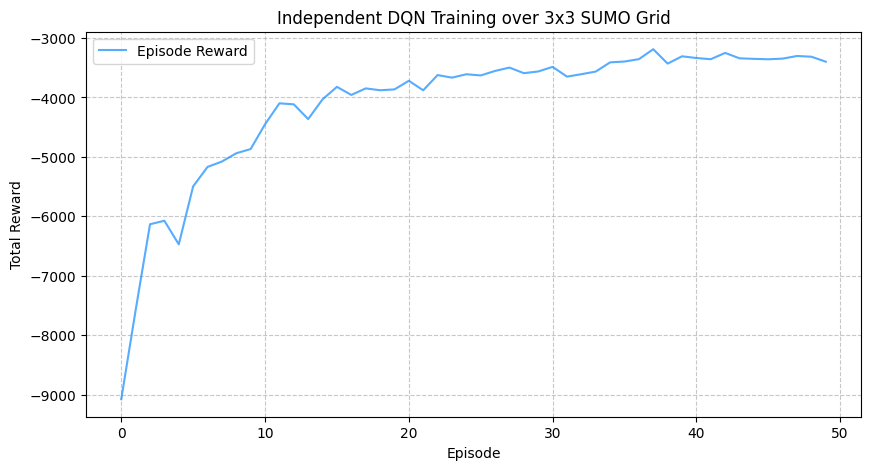

In [12]:
plot_rewards(all_episode_rewards)

In [18]:
def evaluate_model(model_path):
    env = sumo_rl.parallel_env(
        net_file="./env/3x3Grid2lanes.net.xml",
        route_file="./env/routes14000.rou.xml",
        use_gui=True,        # Turn on the SUMO GUI!
        num_seconds=1800,   
        delta_time=5,
        reward_fn="pressure"
    )

    # Load the Trained Model
    q_net = QNetwork(obs_dim, action_dim)
    try:
        q_net.load_state_dict(torch.load(model_path))
        print("Model loaded successfully!")
    except FileNotFoundError:
        print("Error: Could not find the model.")
        return

    # Set network to evaluation modee
    q_net.eval() 

    # Run the Simulation Loop
    observations, infos = env.reset()
    total_evaluation_reward = 0
    
    while env.agents:
        actions = {}
        
        # Pure Exploitation Loop (Epsilon = 0)
        for agent in env.agents:
            obs_tensor = torch.FloatTensor(observations[agent]).unsqueeze(0)
            
            # Disable gradient calculation to save memory and speed up inference
            with torch.no_grad():
                q_values = q_net(obs_tensor)
                # Always pick the action with the highest Q-value
                actions[agent] = torch.argmax(q_values).item() 

        # Step the environment
        observations, rewards, terminations, truncations, infos = env.step(actions)

        # Track the total reward to see how well it did
        for agent in env.agents:
            total_evaluation_reward += rewards[agent]

    print(f"Simulation Finished. Final Total Reward: {total_evaluation_reward:.2f}")
    env.close()

In [ ]:
evaluate_model(model_path)

 Retrying in 1 seconds
Step #0.00 (0ms ?*RT. ?UPS, TraCI: 29ms, vehicles TOT 0 ACT 0 BUF 0)                     
Model loaded successfully!
 Retrying in 1 seconds
